### This notebook is made to practice the KMeans Clustering On IPL Ball-to-ball dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("IPL_Ball_by_Ball_2008_2022.csv")

In [3]:
print(df.shape)
print(df.isnull().mean()*100)
print(df.head())

(225954, 17)
ID                    0.000000
innings               0.000000
overs                 0.000000
ballnumber            0.000000
batter                0.000000
bowler                0.000000
non-striker           0.000000
extra_type           94.667499
batsman_run           0.000000
extras_run            0.000000
total_run             0.000000
non_boundary          0.000000
isWicketDelivery      0.000000
player_out           95.064925
kind                 95.064925
fielders_involved    96.464767
BattingTeam           0.000000
dtype: float64
        ID  innings  overs  ballnumber       batter          bowler  \
0  1312200        1      0           1  YBK Jaiswal  Mohammed Shami   
1  1312200        1      0           2  YBK Jaiswal  Mohammed Shami   
2  1312200        1      0           3   JC Buttler  Mohammed Shami   
3  1312200        1      0           4  YBK Jaiswal  Mohammed Shami   
4  1312200        1      0           5  YBK Jaiswal  Mohammed Shami   

   non-striker ext

In [5]:
df.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


In [14]:
# Total runs by batsman
df.groupby('batter')[['batsman_run','extras_run','total_run']].sum().sort_values(by='total_run',ascending=False)

,batsman_run,extras_run,total_run
batter,,,
V Kohli,6634,242,6876
S Dhawan,6244,317,6561
DA Warner,5883,308,6191
RG Sharma,5881,202,6083
SK Raina,5536,244,5780
...,...,...,...
SS Cottrell,0,0,0
AS Roy,0,0,0
Akash Deep,0,0,0


In [5]:
# Getting batters who have played/faced at least 100 balls
mask = df.groupby('batter')['batter'].count()
players = mask[mask>100].index.tolist()
df = df[df['batter'].isin(players)].copy()

In [14]:
# So we have now the dataset where all the batters have played at least 100 balls
mask1 = df.groupby('batter').agg({'total_run':'sum', 'ballnumber':'count','isWicketDelivery':'sum'})
mask1['strike_rate'] = ((mask1['total_run']/mask1['ballnumber'])*100).round(0)
mask1['batting_avg'] = (mask1['total_run']/mask1['isWicketDelivery']).round(0)
mask1.sort_values(by=['strike_rate','batting_avg'],ascending=False) # Strike rate feature

,total_run,ballnumber,isWicketDelivery,strike_rate,batting_avg
batter,,,,,
AD Russell,2154,1212,66,178.0,33.0
BCJ Cutting,251,146,11,172.0,23.0
K Gowtham,192,115,14,167.0,14.0
LS Livingstone,583,352,20,166.0,29.0
SP Narine,1101,664,64,166.0,17.0
...,...,...,...,...,...
SL Malinga,95,103,12,92.0,8.0
Z Khan,121,141,15,86.0,8.0
Kuldeep Yadav,111,130,5,85.0,22.0


In [15]:
# We have made our dataset which we want to analyse
mask1.head(10)

,total_run,ballnumber,isWicketDelivery,strike_rate,batting_avg
batter,,,,,
A Ashish Reddy,288,196,15,147.0,19.0
A Badoni,173,139,9,124.0,19.0
A Mishra,402,410,30,98.0,13.0
A Symonds,1028,781,26,132.0,40.0
AA Jhunjhunwala,235,218,14,108.0,17.0
AB Agarkar,193,160,8,121.0,24.0
AB McDonald,130,103,5,126.0,26.0
AB de Villiers,5354,3487,125,154.0,43.0
AC Gilchrist,2215,1555,76,142.0,29.0


In [36]:
final_df = mask1[['strike_rate','batting_avg']]

### Now We will perform EDA based on Strike Rates and Batting Average
#### Univariate Analysis

In [37]:
for i,col in enumerate(final_df.columns.to_list()):
    print(i,col)

0 strike_rate
1 batting_avg


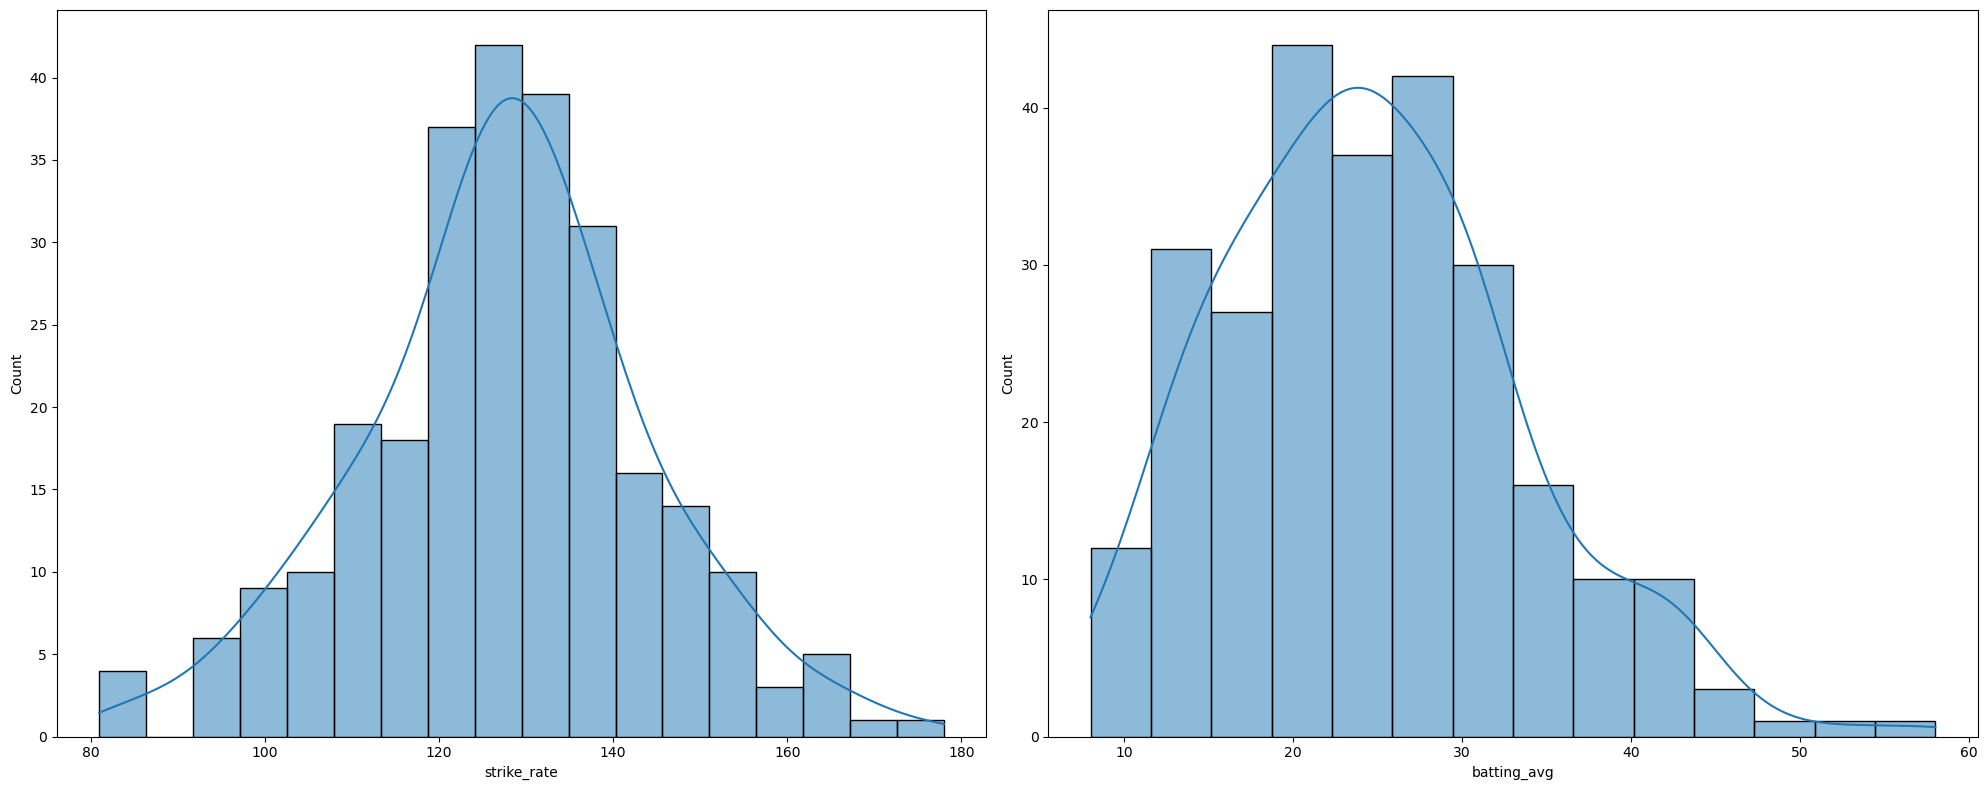

In [40]:
fig,ax = plt.subplots( ncols=2 , figsize=(20,8))
ax = ax.flatten()
for i, col in enumerate(final_df.columns.to_list()):

    sns.histplot(data=final_df , x = col , ax=ax[i] , kde=True)
plt.tight_layout()
plt.show()

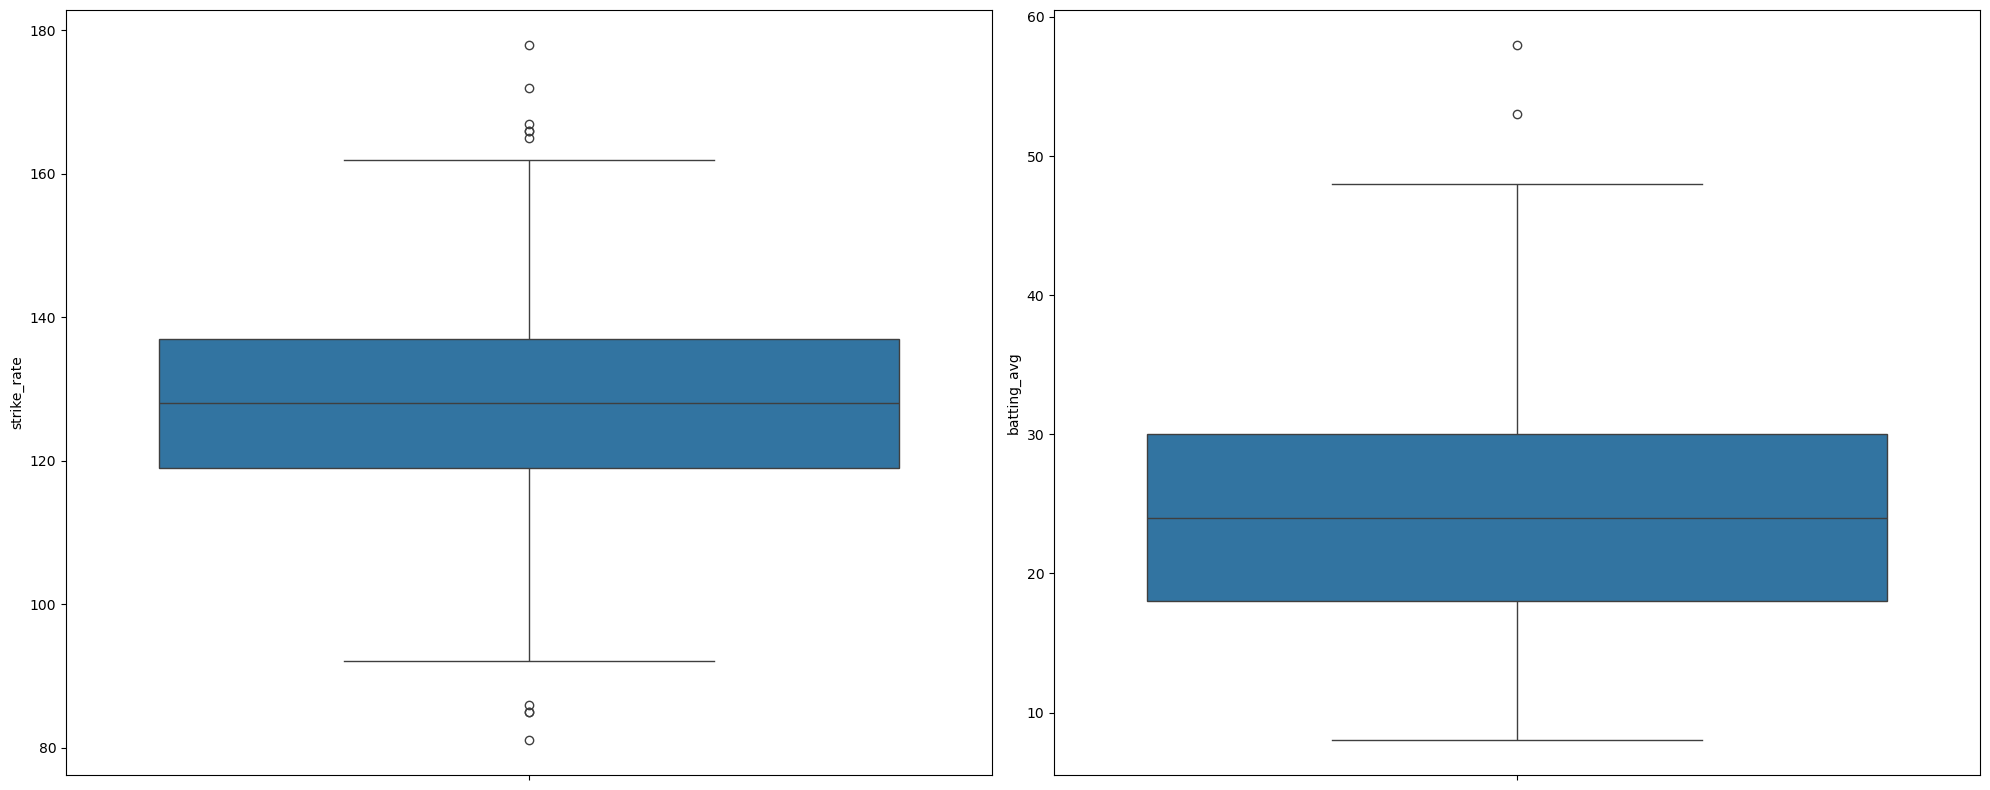

In [41]:
# Checking the outliers
plt.figure(figsize=(20,8))
plt.subplot(121)
sns.boxplot(final_df['strike_rate'])
plt.subplot(122)
sns.boxplot(final_df['batting_avg'])
plt.tight_layout()
plt.show()


- A few outliers in Strike rate
- Only 2 outliers in Batting Avg

### Bivariate Analysis

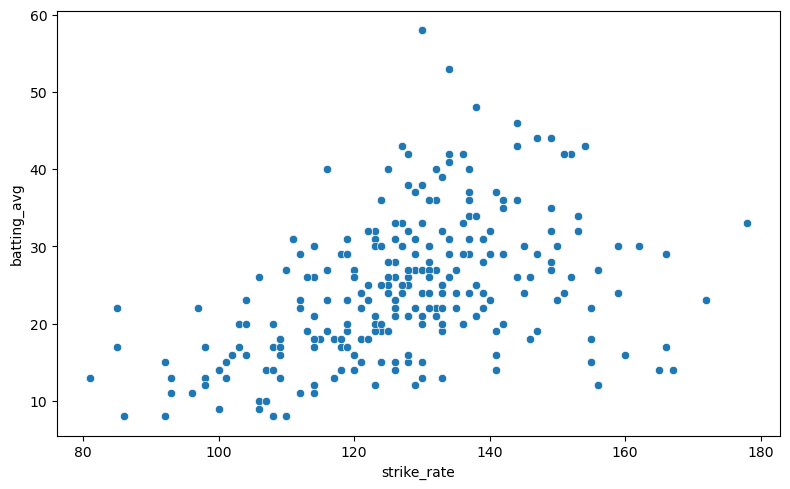

In [44]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=mask1 , x='strike_rate',y='batting_avg')
plt.tight_layout()
plt.show()


In [47]:
### Let us now make Clusters using KMeans
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_init=10 , n_clusters = i)
    kmeans.fit(final_df)
    wcss.append(kmeans.inertia_)


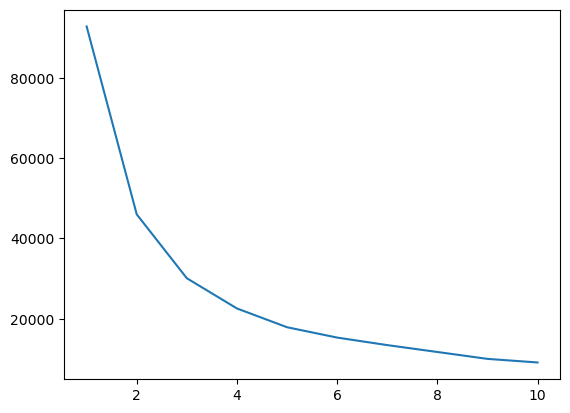

In [49]:
plt.plot(range(1,11) , wcss)
plt.show()

- The best return value can be with cluster = 3 or cluster = 4
Let us make it one by one

In [63]:
X = final_df.iloc[:,:].values

km = KMeans(n_init=20 , n_clusters=4)
y_pred = km.fit_predict(X)

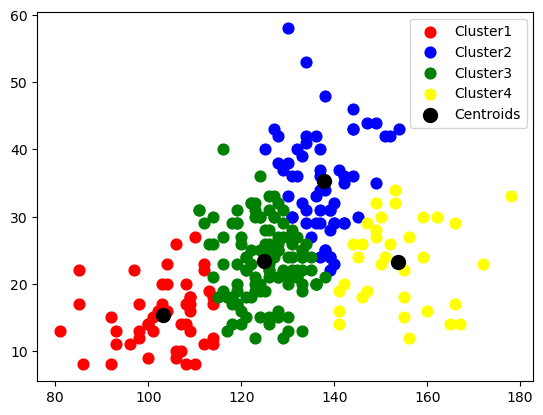

In [64]:
# Plot the clusters
plt.scatter(X[y_pred == 0, 0], X[y_pred == 0, 1], s = 60, c = 'red', label = 'Cluster1')
plt.scatter(X[y_pred == 1, 0], X[y_pred == 1, 1], s = 60, c = 'blue', label = 'Cluster2')
plt.scatter(X[y_pred == 2, 0], X[y_pred == 2, 1], s = 60, c = 'green', label = 'Cluster3')
plt.scatter(X[y_pred == 3, 0], X[y_pred == 3, 1], s = 60, c = 'yellow', label = 'Cluster4')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s = 100, c = 'black', label = 'Centroids')

plt.legend()

plt.show()